In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sqlalchemy import create_engine
import seaborn as sns  
# Connexion PostgreSQL (adapter avec ton .env)
DB_USER = "postgres"
DB_PASS = "kdh"
DB_HOST = "localhost"
DB_PORT = "5432"
DB_NAME = "logiops"

engine = create_engine(f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")


In [4]:
df_class = pd.read_sql("SELECT * FROM clean_class_based_storage", engine)
df_location = pd.read_sql("SELECT * FROM clean_storage_location", engine)
df_support = pd.read_sql("SELECT * FROM clean_support_points", engine)

df_class.head()


,location,class,referenceproduit,quantity,storage_type
0,A-14-11,C,8551FLX,15.0,class_based
1,A-14-11,C,C5O9C9,4.0,class_based
2,A-14-11,C,VF002,9.5,class_based
3,A-14-11,C,2149XPC,13.0,class_based
4,A-14-11,C,12261XP,7.0,class_based


In [6]:
tables = {
    "class_based": "clean_class_based_storage",
    "random": "clean_random_storage",
    "dedicated": "clean_dedicated_storage",
    "location": "clean_storage_location",
    "support": "clean_support_points",
    "unified": "unified_storage_view"
}

In [19]:
df_class = pd.read_sql(f"SELECT * FROM {tables['class_based']}", engine)
df_random = pd.read_sql(f"SELECT * FROM {tables['random']}", engine)
df_dedicated = pd.read_sql(f"SELECT * FROM {tables['dedicated']}", engine)
df_location = pd.read_sql(f"SELECT * FROM {tables['location']}", engine)
df_support = pd.read_sql(f"SELECT * FROM {tables['support']}", engine)
df_unified = pd.read_sql(f"SELECT * FROM {tables['unified']}", engine)

In [20]:

#  Regroupement global
df_all = pd.concat([
    df_class[['location', 'referenceproduit', 'quantity', 'storage_type']],
    df_random[['location', 'referenceproduit', 'quantity', 'storage_type']],
    df_dedicated[['location', 'referenceproduit', 'quantity', 'storage_type']]
], ignore_index=True)


C:\Users\khmai\AppData\Local\Temp\ipykernel_3688\3708476452.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_quantite, x='storage_type', y='total_quantity', palette='viridis')


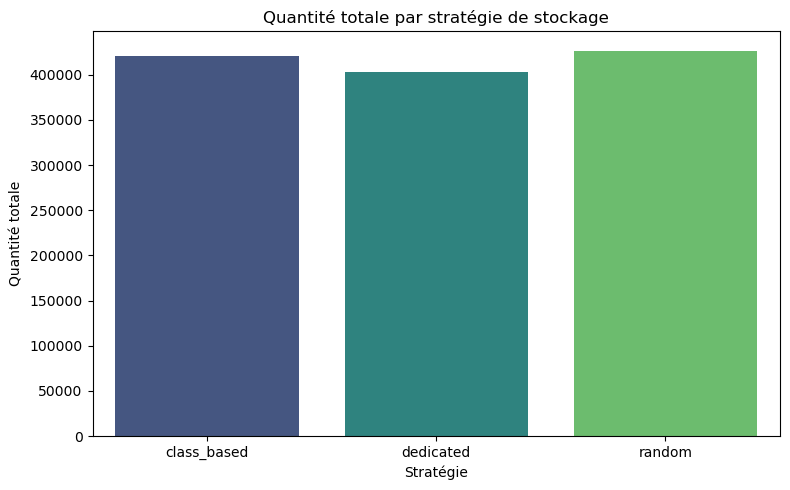

In [10]:
# Quantité et diversité par stratégie
kpi_quantite = df_all.groupby('storage_type').agg(
    total_quantity=('quantity', 'sum'),
    nb_references=('referenceproduit', 'nunique'),
    nb_locations=('location', 'nunique')
).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=kpi_quantite, x='storage_type', y='total_quantity', palette='viridis')
plt.title("Quantité totale par stratégie de stockage")
plt.ylabel("Quantité totale")
plt.xlabel("Stratégie")
plt.tight_layout()
plt.show()


C:\Users\khmai\AppData\Local\Temp\ipykernel_3688\974864665.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_utilization, x='storage_type', y='avg_utilization_rate', palette='coolwarm')


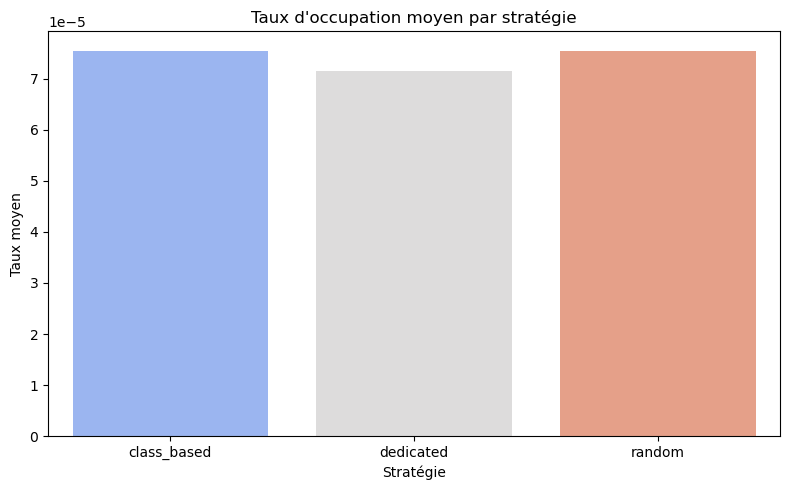

In [11]:
#Taux d'occupation moyen par stratégie
df_merged = df_all.merge(df_location[['location', 'volume']], on='location', how='left')
df_merged['utilization_rate'] = df_merged['quantity'] / df_merged['volume']

kpi_utilization = df_merged.groupby('storage_type').agg(
    avg_utilization_rate=('utilization_rate', 'mean'),
    total_volume=('volume', 'sum')
).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=kpi_utilization, x='storage_type', y='avg_utilization_rate', palette='coolwarm')
plt.title("Taux d'occupation moyen par stratégie")
plt.ylabel("Taux moyen")
plt.xlabel("Stratégie")
plt.tight_layout()
plt.show()

C:\Users\khmai\AppData\Local\Temp\ipykernel_3688\3603137052.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=kpi_class, x='class', y='total_quantity', palette='magma')


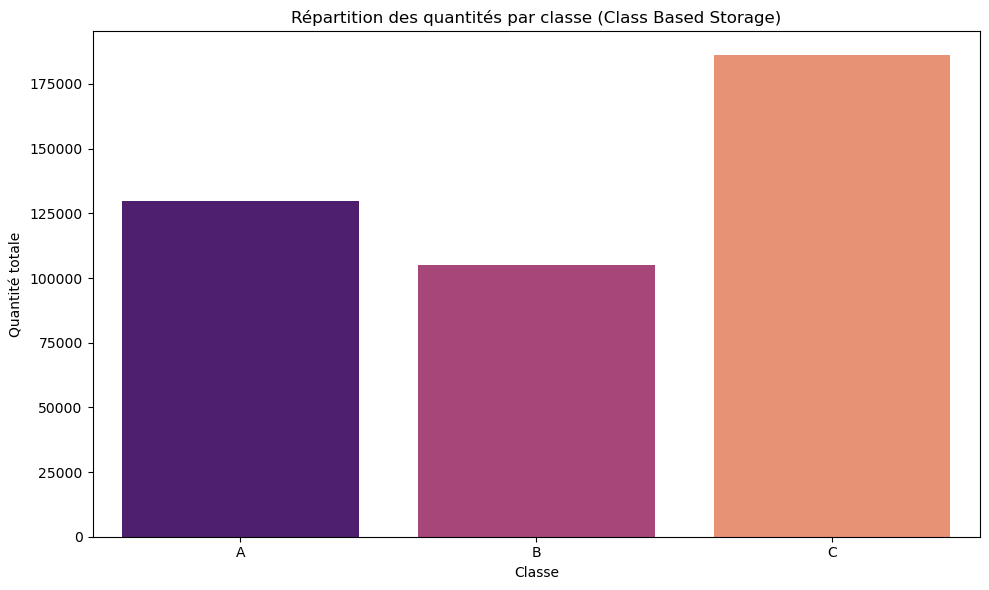

In [12]:
# Répartition des produits par classe
kpi_class = df_class.groupby('class').agg(
    nb_references=('referenceproduit', 'nunique'),
    total_quantity=('quantity', 'sum')
).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=kpi_class, x='class', y='total_quantity', palette='magma')
plt.title("Répartition des quantités par classe (Class Based Storage)")
plt.ylabel("Quantité totale")
plt.xlabel("Classe")
plt.tight_layout()
plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\+'
<>:17: SyntaxWarning: invalid escape sequence '\+'
C:\Users\khmai\AppData\Local\Temp\ipykernel_3688\2436231294.py:17: SyntaxWarning: invalid escape sequence '\+'
  multi_strategy = df_unified[df_unified['strategies'].str.count('\+') >= 1]
C:\Users\khmai\AppData\Local\Temp\ipykernel_3688\2436231294.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


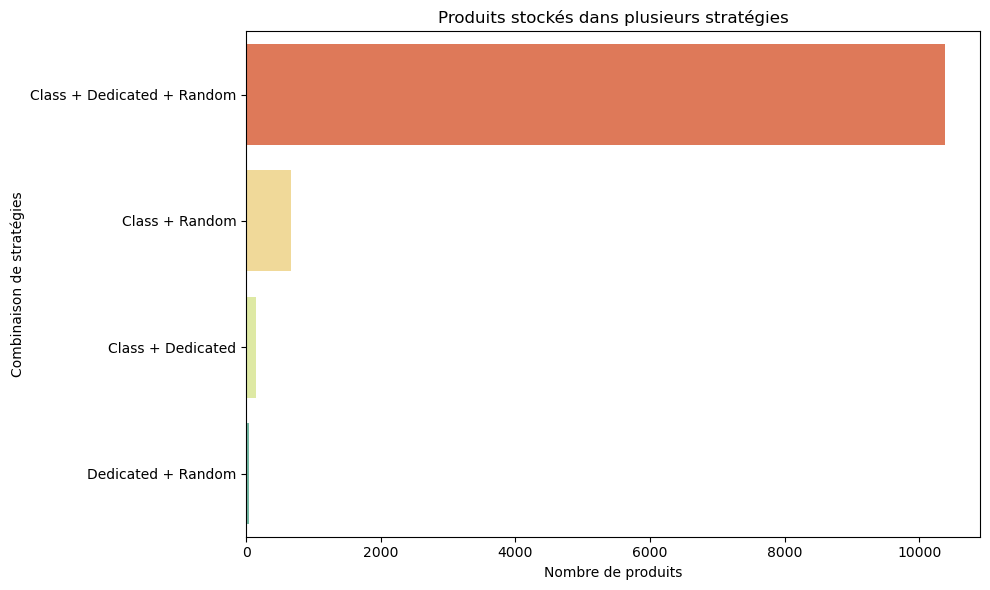

In [13]:
# Produits stockés dans plusieurs stratégies (Graphique)


def get_strategy_combo(row):
    combo = []
    if row['qty_class_based'] > 0:
        combo.append("Class")
    if row['qty_dedicated'] > 0:
        combo.append("Dedicated")
    if row['qty_random'] > 0:
        combo.append("Random")
    return " + ".join(combo)

df_unified['strategies'] = df_unified.apply(get_strategy_combo, axis=1)


multi_strategy = df_unified[df_unified['strategies'].str.count('\+') >= 1]


strategy_counts = multi_strategy['strategies'].value_counts().reset_index()
strategy_counts.columns = ['combinaison', 'nombre_produits']

# Visualisation en bar chart
plt.figure(figsize=(10,6))
sns.barplot(
    data=strategy_counts,
    x='nombre_produits',
    y='combinaison',
    palette='Spectral'
)
plt.title("Produits stockés dans plusieurs stratégies")
plt.xlabel("Nombre de produits")
plt.ylabel("Combinaison de stratégies")
plt.tight_layout()
plt.show()


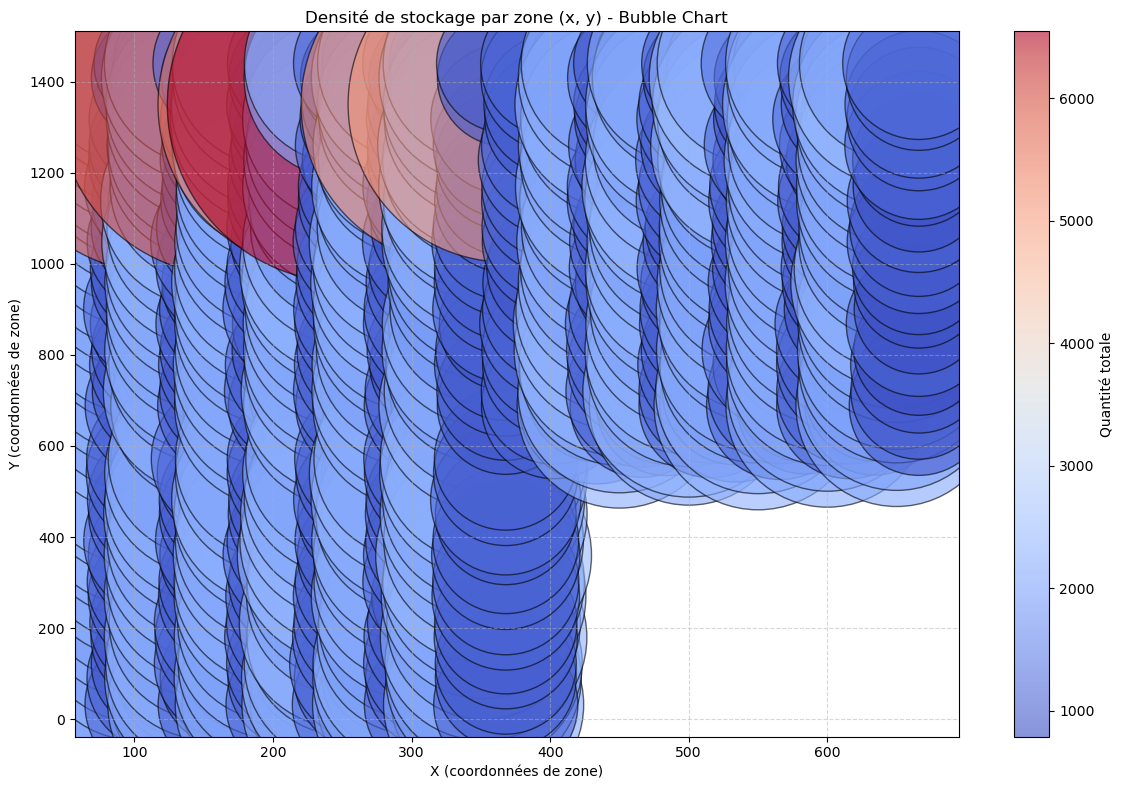

In [14]:
# Densité par zone (x, y) 
df_zone = df_location.merge(df_all, on='location', how='left')
df_zone_grouped = df_zone.groupby(['x','y']).agg(
    total_quantity=('quantity','sum')
).reset_index()

plt.figure(figsize=(12,8))
bubble = plt.scatter(
    df_zone_grouped['x'],
    df_zone_grouped['y'],
    s=df_zone_grouped['total_quantity'] * 10, 
    c=df_zone_grouped['total_quantity'],
    cmap='coolwarm',
    alpha=0.6,
    edgecolors='k'
)

plt.colorbar(bubble, label='Quantité totale')
plt.title("Densité de stockage par zone (x, y) - Bubble Chart")
plt.xlabel("X (coordonnées de zone)")
plt.ylabel("Y (coordonnées de zone)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


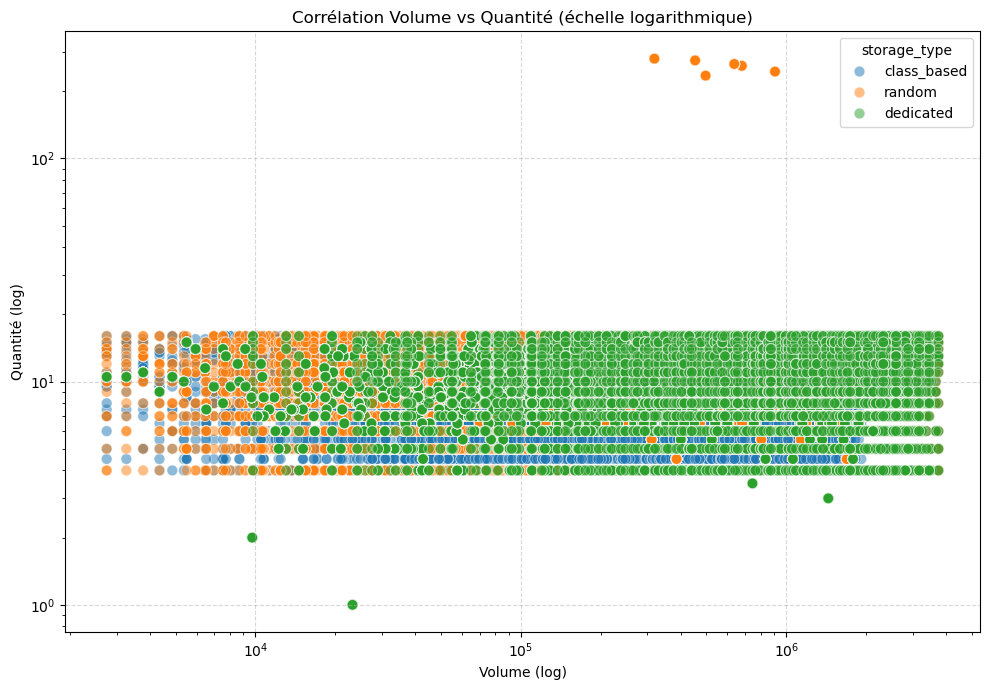

In [15]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=df_merged,
    x='volume',
    y='quantity',
    hue='storage_type',
    alpha=0.5,
    s=60
)
plt.xscale('log')
plt.yscale('log')
plt.title("Corrélation Volume vs Quantité (échelle logarithmique)")
plt.xlabel("Volume (log)")
plt.ylabel("Quantité (log)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


C:\Users\khmai\AppData\Local\Temp\ipykernel_3688\3176370278.py:23: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(data=df_melted, x='storage_type', y='quantity', ci='sd', ax=ax)


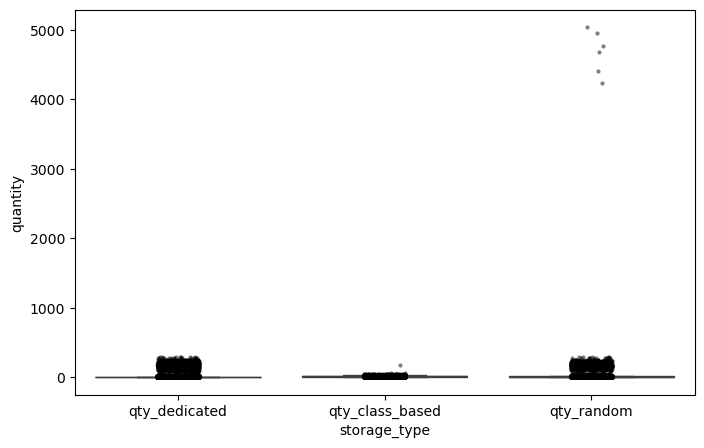

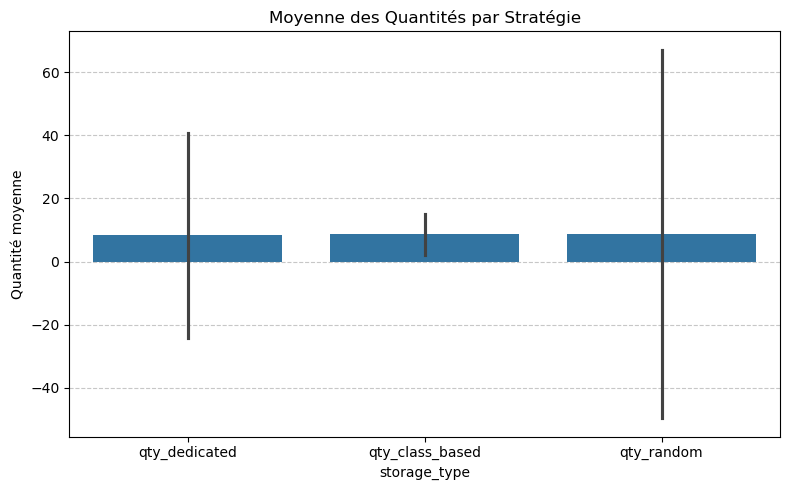

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_melted = df_unified.melt(
    value_vars=['qty_dedicated','qty_class_based', 'qty_random'],
    var_name='storage_type',
    value_name='quantity'
)

fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(data=df_melted, x='storage_type', y='quantity', ax=ax, showfliers=False)
sns.stripplot(data=df_melted, x='storage_type', y='quantity',
              color='black', size=3, alpha=0.5, ax=ax)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_melted, x='storage_type', y='quantity', ci='sd', ax=ax)
plt.title("Moyenne des Quantités par Stratégie")
plt.ylabel("Quantité moyenne")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [30]:
cols = ['qty_dedicated', 'qty_class_based', 'qty_random']
stats = df_unified[cols].describe().T
stats['non_null_ratio'] = df_unified[cols].notna().mean() * 100
print(stats)

                   count      mean        std  min  25%  50%   75%     max  \
qty_dedicated    48790.0  8.264788  32.400530  0.0  0.0  0.0   0.0   288.0   
qty_class_based  48790.0  8.626184   6.412936  0.0  4.0  9.0  13.0   171.0   
qty_random       48790.0  8.744005  58.434286  0.0  0.0  0.0   9.0  5040.0   

                 non_null_ratio  
qty_dedicated             100.0  
qty_class_based           100.0  
qty_random                100.0  


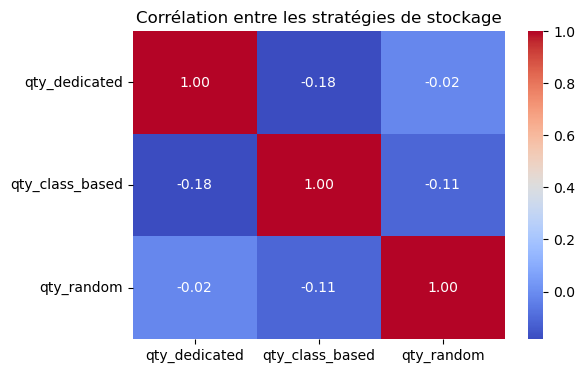

In [31]:
corr = df_unified[cols].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Corrélation entre les stratégies de stockage")
plt.show()


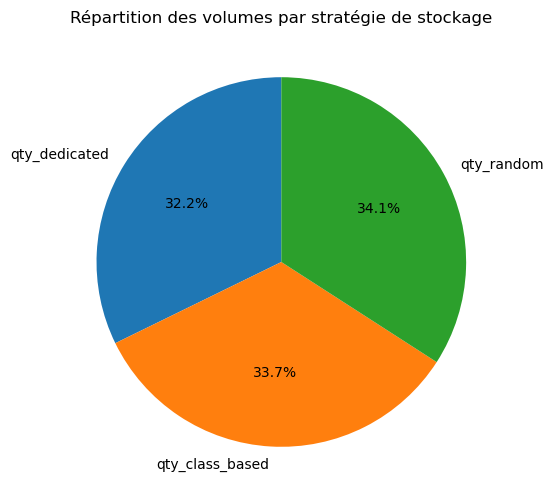

In [32]:
total_per_strategy = df_unified[cols].sum()
plt.figure(figsize=(6, 6))
plt.pie(total_per_strategy, labels=total_per_strategy.index, autopct='%1.1f%%', startangle=90)
plt.title("Répartition des volumes par stratégie de stockage")
plt.show()


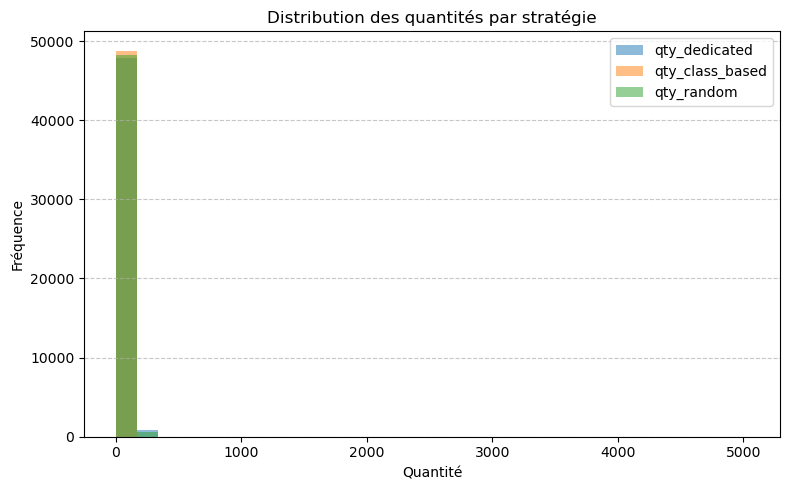

In [34]:
#Distribution individuelle par histogramme
df_unified[cols].plot(kind='hist', alpha=0.5, bins=30, figsize=(8, 5))
plt.title("Distribution des quantités par stratégie")
plt.xlabel("Quantité")
plt.ylabel("Fréquence")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


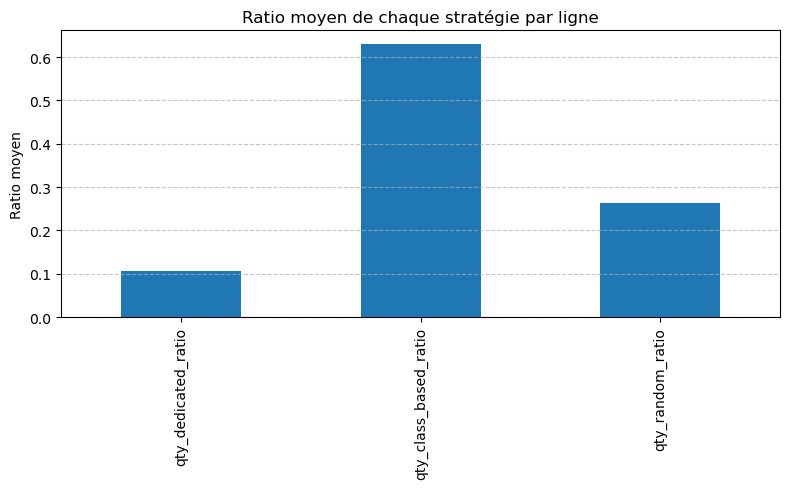

In [35]:
df_unified['total_qty'] = df_unified[cols].sum(axis=1)
for c in cols:
    df_unified[f'{c}_ratio'] = df_unified[c] / df_unified['total_qty']

# Visualisation des ratios moyens
avg_ratios = df_unified[[f'{c}_ratio' for c in cols]].mean()
avg_ratios.plot(kind='bar', figsize=(8, 5))
plt.title("Ratio moyen de chaque stratégie par ligne")
plt.ylabel("Ratio moyen")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [37]:
#Repérer les valeurs aberrantes (volumes anormalement hauts/bas par stratégie) via un modèle Isolation Forest.
from sklearn.ensemble import IsolationForest
import numpy as np

cols = ['qty_dedicated', 'qty_class_based', 'qty_random']
X = df_unified[cols].fillna(0)

iso = IsolationForest(contamination=0.05, random_state=42)
df_unified['anomaly'] = iso.fit_predict(X)

# -1 = anomalie, 1 = normal
anomalies = df_unified[df_unified['anomaly'] == -1]
print(f"Nombre d'anomalies détectées: {len(anomalies)}")


Nombre d'anomalies détectées: 2352


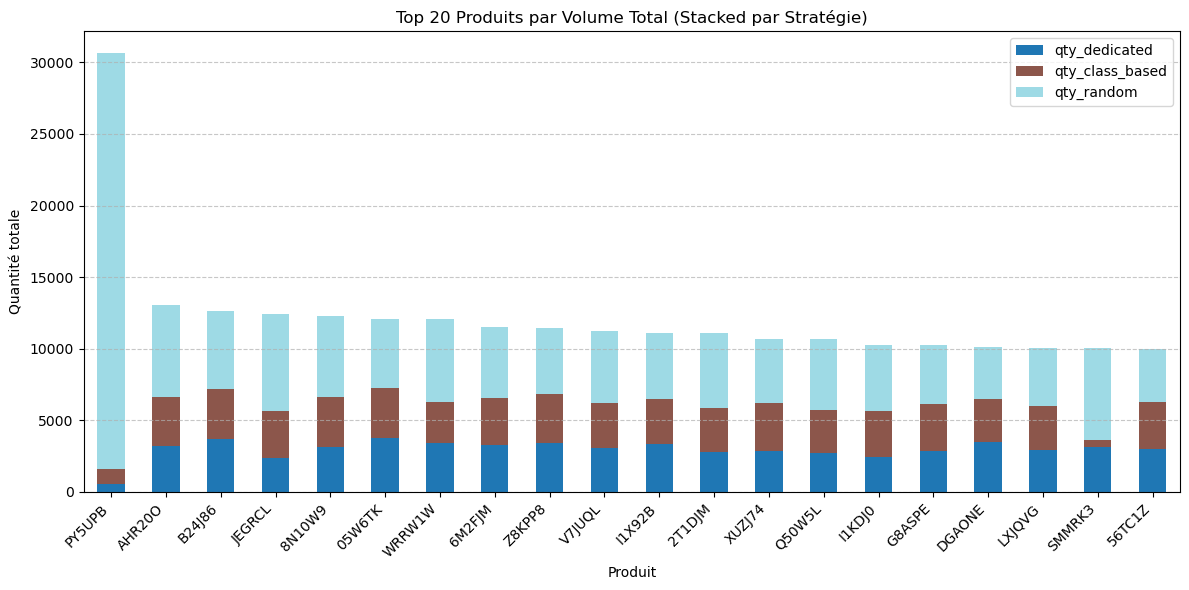

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Colonnes utilisées
cols = ['qty_dedicated', 'qty_class_based', 'qty_random']

# Agrégation par produit
df_products = df_unified.groupby('referenceproduit')[cols].sum()

# Ajout du total
df_products['total_qty'] = df_products.sum(axis=1)

# Tri et sélection du Top 20
top20 = df_products.sort_values(by='total_qty', ascending=False).head(20)

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
top20[['qty_dedicated', 'qty_class_based', 'qty_random']].plot(
    kind='bar',
    stacked=True,
    ax=ax,
    colormap='tab20'
)
plt.title("Top 20 Produits par Volume Total (Stacked par Stratégie)")
plt.xlabel("Produit")
plt.ylabel("Quantité totale")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


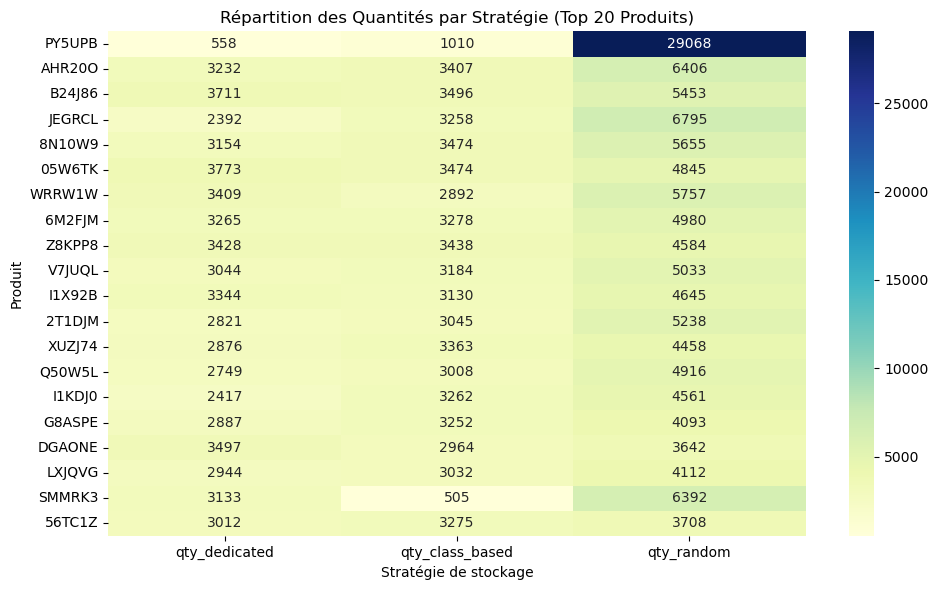

In [46]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(
    top20[['qty_dedicated', 'qty_class_based', 'qty_random']],
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)
plt.title("Répartition des Quantités par Stratégie (Top 20 Produits)")
plt.xlabel("Stratégie de stockage")
plt.ylabel("Produit")
plt.tight_layout()
plt.show()
